In [1]:
# ============================================================
# 5-spin cell, 2-cell cluster Niemeyer-van Leeuwen
# Drop-in companion to your 3-spin code.
# Imports logsumexp and build_J from your existing utils.py
# ============================================================

import numpy as np
from numba import njit
from itertools import product
import matplotlib.pyplot as plt

# Reuse your existing utilities
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'lib')))
from utils import logsumexp, build_J

# ---- Cell geometry constants (5-spin contiguous) ----
__cell_geometry__ = "contiguous_5spin"
CELL_SIZE = 5
B = 5  # length-rescaling factor

# All 2^5 = 32 spin configurations
_all_spins5 = np.array(list(product([-1, 1], repeat=CELL_SIZE)), dtype=np.int64)
plus_configs5  = _all_spins5[np.sum(_all_spins5, axis=1) >=  1]   # 16 configs
minus_configs5 = _all_spins5[np.sum(_all_spins5, axis=1) <= -1]   # 16 configs

# ---- Distance / scale bookkeeping ----
@njit(cache=True)
def required_initial_max_distance_5(max_dist_final, n_steps):
    """Inverse of r_max: how big D_0 must be to support n_steps with final D = max_dist_final."""
    D = max_dist_final
    for _ in range(n_steps):
        D = B * D + (CELL_SIZE - 1)   # 5*D + 4
    return D

@njit(cache=True)
def r_max_5(D):
    """Largest renormalized r' available given current J array length D+1."""
    return (D - (CELL_SIZE - 1)) // B   # (D - 4) // 5

@njit(cache=True)
def determine_r_max_5(D):
    return r_max_5(D)

# ---- Intracell energy: 10 pairs per cell ----
@njit(cache=True)
def intracell_energies_5(spins, J):
    """
    spins: (n, 5) array of +/-1
    Returns array of intracell energies, summing J[|i-j|] * s_i * s_j over all 10 pairs.
    """
    n = spins.shape[0]
    D = len(J) - 1
    E = np.empty(n, dtype=np.float64)
    for k in range(n):
        e = 0.0
        for i in range(CELL_SIZE):
            for j in range(i + 1, CELL_SIZE):
                d = j - i  # distances 1..4
                if d <= D:
                    e += J[d] * spins[k, i] * spins[k, j]
        E[k] = e
    return E

# ---- log R(++), R(+-) for renormalized J at separation r ----
@njit(cache=True)
def log_Rpp_Rpm_5(r, J):
    """
    r: renormalized separation (cells are b*r physical sites apart, center-to-center;
       contiguously stacked, so right cell starts at position 1 + 5*r).
    """
    D = len(J) - 1
    E_plus  = intracell_energies_5(plus_configs5,  J)
    E_minus = intracell_energies_5(minus_configs5, J)

    # Physical positions
    left_pos  = np.array([1, 2, 3, 4, 5], dtype=np.int64)
    # For r=1, right cell occupies [6,7,8,9,10]; for r=2, [11..15], etc.
    right_pos = np.empty(CELL_SIZE, dtype=np.int64)
    for k in range(CELL_SIZE):
        right_pos[k] = 6 + k + CELL_SIZE * (r - 1)

    # 5x5 distance matrix
    distances = np.empty((CELL_SIZE, CELL_SIZE), dtype=np.int64)
    for a in range(CELL_SIZE):
        for b_ in range(CELL_SIZE):
            distances[a, b_] = abs(right_pos[b_] - left_pos[a])

    n_plus  = plus_configs5.shape[0]
    n_minus = minus_configs5.shape[0]

    # ---- R(++) ----
    totals_pp = np.empty(n_plus * n_plus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_configs5[iL]
        EL = E_plus[iL]
        for iR in range(n_plus):
            sR = plus_configs5[iR]
            ER = E_plus[iR]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pp[idx] = EL + ER + E_int
            idx += 1

    # ---- R(+-) ----
    totals_pm = np.empty(n_plus * n_minus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_configs5[iL]
        EL = E_plus[iL]
        for iR in range(n_minus):
            sR = minus_configs5[iR]
            ER = E_minus[iR]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pm[idx] = EL + ER + E_int
            idx += 1

    log_pp = logsumexp(totals_pp)
    log_pm = logsumexp(totals_pm)
    return log_pp, log_pm

# ---- log R(++), R(--) at nonzero H, used for field recursion (r=1) ----
@njit(cache=True)
def log_Rpp_Rmm_nonzero_H_5(J, H):
    E_plus  = intracell_energies_5(plus_configs5,  J)
    E_minus = intracell_energies_5(minus_configs5, J)

    left_pos  = np.array([1, 2, 3, 4, 5], dtype=np.int64)
    right_pos = np.array([6, 7, 8, 9, 10], dtype=np.int64)

    distances = np.empty((CELL_SIZE, CELL_SIZE), dtype=np.int64)
    for a in range(CELL_SIZE):
        for b_ in range(CELL_SIZE):
            distances[a, b_] = abs(right_pos[b_] - left_pos[a])

    D = len(J) - 1
    n_plus  = plus_configs5.shape[0]
    n_minus = minus_configs5.shape[0]

    # R(++)
    totals_pp = np.empty(n_plus * n_plus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_configs5[iL]
        EL = E_plus[iL]
        magL = sL[0] + sL[1] + sL[2] + sL[3] + sL[4]
        for iR in range(n_plus):
            sR = plus_configs5[iR]
            ER = E_plus[iR]
            magR = sR[0] + sR[1] + sR[2] + sR[3] + sR[4]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pp[idx] = EL + ER + E_int + H * (magL + magR)
            idx += 1

    # R(--)
    totals_mm = np.empty(n_minus * n_minus, dtype=np.float64)
    idx = 0
    for iL in range(n_minus):
        sL = minus_configs5[iL]
        EL = E_minus[iL]
        magL = sL[0] + sL[1] + sL[2] + sL[3] + sL[4]
        for iR in range(n_minus):
            sR = minus_configs5[iR]
            ER = E_minus[iR]
            magR = sR[0] + sR[1] + sR[2] + sR[3] + sR[4]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_mm[idx] = EL + ER + E_int + H * (magL + magR)
            idx += 1

    log_pp = logsumexp(totals_pp)
    log_mm = logsumexp(totals_mm)
    return log_pp, log_mm

# ---- RG step ----
@njit(cache=True)
def rg_step_5(J, a=None):
    D = len(J) - 1
    rmax = determine_r_max_5(D)

    J_new = np.zeros_like(J)
    J_new[0] = 0.0

    # Head: exact (cluster) renormalization
    for r in range(1, rmax + 1):
        log_R_pp, log_R_pm = log_Rpp_Rpm_5(r, J)
        J_new[r] = 0.5 * (log_R_pp - log_R_pm)

    # Tail: power-law continuation if exponent provided
    if a is not None:
        anchor = J_new[rmax]
        for r in range(rmax + 1, D + 1):
            J_new[r] = anchor * (rmax / r) ** a

    return J_new

@njit(cache=True)
def renormalized_field_5(J, H):
    log_pp, log_mm = log_Rpp_Rmm_nonzero_H_5(J, H)
    return 0.25 * (log_pp - log_mm)

# ---- Critical coupling search (bisection on J0) ----
def find_Jc_5(a, Jlow=1e-2, Jhigh=1e2, max_steps=6, max_dist_final=9,
              tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3):
    def grows(J0):
        D0 = required_initial_max_distance_5(max_dist_final, max_steps)
        J = build_J(J0, a, D0)
        J1_initial = abs(J[1])
        for _ in range(max_steps):
            if abs(J[1]) > growth_threshold:
                return True
            if abs(J[1]) < decay_threshold:
                return False
            J = rg_step_5(J)
        return abs(J[1]) > J1_initial

    while (Jhigh - Jlow) > tol:
        Jmid = 0.5 * (Jlow + Jhigh)
        if grows(Jmid):
            Jhigh = Jmid
        else:
            Jlow = Jmid
    return 0.5 * (Jlow + Jhigh)

# ============================================================
# Flow visualization (mirrors your existing notebook code)
# ============================================================

def generate_rg_flow_5(J0, a, max_dist_final, n_steps):
    D0 = required_initial_max_distance_5(max_dist_final, n_steps)
    J = build_J(J0, a, D0)
    J_list = [J.copy()]
    for step in range(n_steps):
        J = rg_step_5(J)
        J_list.append(J.copy())
    return J_list

def extract_flows_5(J_list, max_dist_final):
    n_rec = len(J_list)
    flows = np.zeros((n_rec, max_dist_final + 1), dtype=float)
    for step, J in enumerate(J_list):
        D_curr = len(J) - 1
        r_keep = min(max_dist_final, D_curr)
        flows[step, :r_keep + 1] = J[:r_keep + 1]
    return flows

def plot_rg_flow_5(flows, distances_to_plot=None, fig_name=None):
    n_rec, _ = flows.shape
    max_dist = flows.shape[1] - 1
    steps = np.arange(n_rec)
    if distances_to_plot is None:
        distances_to_plot = range(1, max_dist + 1)
    plt.figure(figsize=(7, 5))
    for r in distances_to_plot:
        if 1 <= r <= max_dist:
            plt.plot(steps, flows[:, r], marker='o', label=f"${r}$")
    plt.xlim(0, None)
    plt.xlabel(r"RG iteration number $k$", fontsize=14)
    plt.ylabel(r"Interaction $J_r$", fontsize=14)
    plt.legend(title="$r$", title_fontsize=12)
    plt.tight_layout()
    if fig_name:
        plt.savefig(fig_name)
    plt.show()

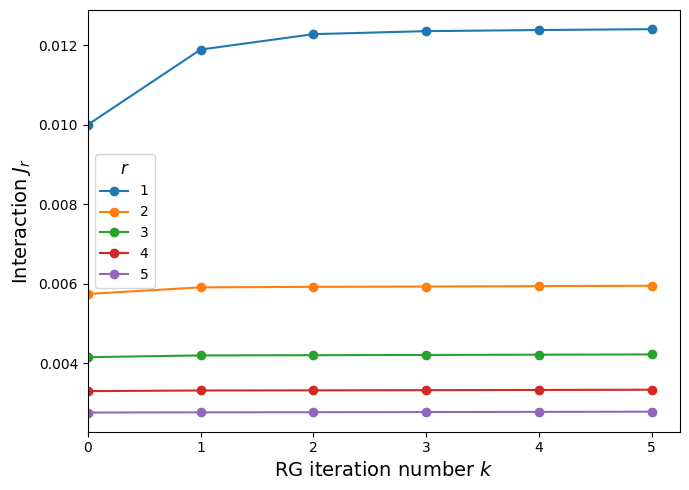

In [19]:
T = 100
J0 = 1.0 / T
a = 0.8
max_dist_final = 9
n_steps = 5

J_list = generate_rg_flow_5(J0, a, max_dist_final, n_steps)
flows = extract_flows_5(J_list, max_dist_final)
plot_rg_flow_5(flows, distances_to_plot=[1, 2, 3, 4, 5])

a = 0.7000  →  Jc = 0.001, Tc = 9.96e+02
a = 0.8643  →  Jc = 0.0301, Tc = 33.2
a = 1.0286  →  Jc = 0.115, Tc = 8.72
a = 1.1929  →  Jc = 0.198, Tc = 5.05
a = 1.3571  →  Jc = 0.286, Tc = 3.5
a = 1.5214  →  Jc = 0.384, Tc = 2.6
a = 1.6857  →  Jc = 0.5, Tc = 2.0
a = 1.8500  →  Jc = 0.649, Tc = 1.54
a = 2.0143  →  Jc = 0.861, Tc = 1.16
a = 2.1786  →  Jc = 1.21, Tc = 0.824
a = 2.3429  →  Jc = 1.83, Tc = 0.547
a = 2.5071  →  Jc = 2.71, Tc = 0.368
a = 2.6714  →  Jc = 3.8, Tc = 0.263
a = 2.8357  →  Jc = 5.05, Tc = 0.198
a = 3.0000  →  Jc = 6.48, Tc = 0.154


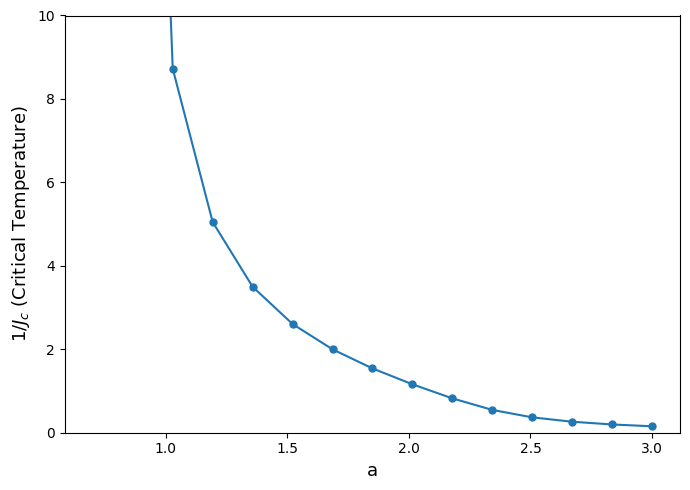

In [23]:
# ============================================================
# Critical line: 5-spin cell version
# Mirrors the 3-spin scan for direct comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# These come from the 5-spin module/notebook cell defined earlier
# from your_5spin_module import find_Jc_5

a_vals = np.linspace(0.7, 3, 15)
Jc_vals_5 = []
Tc_vals_5 = []

for a in a_vals:
    Jc = find_Jc_5(
        a=a,
        Jlow=1e-3, Jhigh=1e3,
        max_steps=5, max_dist_final=9,
        tol=1e-5,
        growth_threshold=1e3, decay_threshold=1e-3
    )
    Jc_vals_5.append(Jc)
    Tc_vals_5.append(1.0 / Jc)
    print(f"a = {a:.4f}  →  Jc = {Jc:.3}, Tc = {1/Jc:.3}")

Jc_vals_5 = np.array(Jc_vals_5)
Tc_vals_5 = np.array(Tc_vals_5)

plt.figure(figsize=(7, 5))
plt.plot(a_vals, Tc_vals_5, 'o-', ms=5, label="5-spin cell")
plt.ylim(0, 10)
plt.xlabel("a", fontsize=13)
plt.ylabel(r"$1/J_c$ (Critical Temperature)", fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()

In [21]:
ipek = np.array([[0.7500,4.52125199],
[0.8000,3.60338191],
[0.9000,2.57710587],
[1.0000,2.01262302],
[1.1000,1.65082931],
[1.2000,1.39555058],
[1.3000,1.20307433],
[1.4000,1.05067106],
[1.5000,0.92526929],
[1.6000,0.81868463],
[1.7000,0.72532446],
[1.8000,0.64086121],
[1.8500,0.60067639],
[1.9000,0.56101569],
[1.9500,0.52090090],
[1.9800,0.49592122],
[2.0000,0.47848769],
[2.0200,0.46001853],
[2.0500,0.42884849],
[2.1000,0.34607338]])

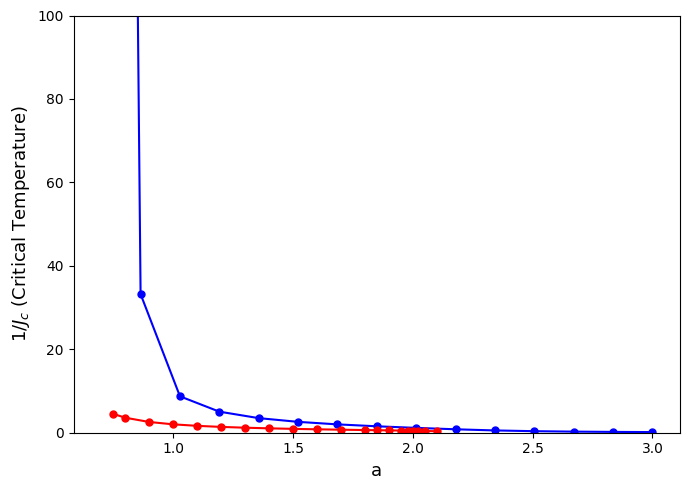

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(a_vals, Tc_vals_5, 'bo-', ms=5, label="5-spin cell")
plt.plot(ipek[::,0], ipek[::,1], 'ro-', ms=5, label="ipek")
plt.ylim(0, 100)
plt.xlabel("a", fontsize=13)
plt.ylabel(r"$1/J_c$ (Critical Temperature)", fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()